<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 02</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Procesos de difusión directa</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Pregunta directriz

> ¿Cómo se construye un proceso probabilístico que transforma gradualmente una muestra de datos en ruido gaussiano?

Los notebooks anteriores formularon el modelado generativo como aprendizaje de una distribución de datos y estudiaron la gaussiana estándar como distribución base. En este notebook aparece el primer mecanismo propio de los modelos de difusión: el proceso directo, también llamado *forward diffusion process*.

La idea no es entrenar todavía una red neuronal. Primero fijamos un proceso probabilístico conocido que toma una muestra limpia $x_0$ y produce versiones progresivamente ruidosas $x_t$. Esta construcción será la base para definir, en notebooks posteriores, el problema inverso: aprender a recuperar estructura desde ruido.


## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular el proceso directo de difusión como una cadena de Markov gaussiana.
2. Distinguir entre la transición local $q(x_t \mid x_{t-1})$ y la forma cerrada $q(x_t \mid x_0)$.
3. Interpretar el papel de $\beta_t$, $\alpha_t$ y $\bar{\alpha}_t$ en la destrucción gradual de información.
4. Simular muestras ruidosas $x_t$ para distintos tiempos $t$ sobre imágenes de QuickDraw.
5. Relacionar visualmente la pérdida de estructura con la relación señal-ruido.
6. Reconocer que el proceso directo no se aprende: es una construcción fija que prepara el problema de denoising.


## Marco conceptual

Un modelo de difusión no comienza aprendiendo a generar imágenes. Comienza definiendo una forma controlada de destruirlas. A partir de una muestra limpia $x_0 \sim p_{\mathrm{data}}$, se construye una sucesión de variables aleatorias

$$
x_0, x_1, x_2, \ldots, x_T,
$$

donde cada $x_t$ es una versión más ruidosa de la muestra original. El objetivo del proceso directo es que, para tiempos grandes, $x_T$ sea aproximadamente indistinguible de ruido gaussiano.

La importancia de esta construcción es conceptual y matemática. Si sabemos cómo transformar datos en ruido mediante un proceso fijo, podemos formular el aprendizaje generativo como el problema inverso: aprender a transformar ruido en datos. Ese problema inverso no se resuelve en este notebook, pero queda motivado por completo.


## Formulación matemática

Sea $x_0 \in \mathbb{R}^d$ una muestra de datos. En este notebook, $d=784$ porque cada imagen de QuickDraw tiene tamaño $28 \times 28$. Trabajaremos con intensidades normalizadas en $[-1,1]$, una convención frecuente en modelos de difusión porque centra los datos alrededor de cero y los coloca en la misma escala conceptual que el ruido gaussiano.

El proceso directo se define mediante una sucesión de varianzas pequeñas

$$
0 < \beta_1, \beta_2, \ldots, \beta_T < 1.
$$

Cada $\beta_t$ controla cuánta varianza gaussiana se agrega en el paso $t$. Definimos

$$
\alpha_t = 1 - \beta_t,
\qquad
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s.
$$

La transición local del proceso directo es una cadena de Markov gaussiana:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}\left(
  \sqrt{\alpha_t}\,x_{t-1},
  \beta_t I
\right).
$$

Equivalente y computacionalmente, podemos escribir un paso de ruido como

$$
x_t
=
\sqrt{\alpha_t}\,x_{t-1}
+
\sqrt{\beta_t}\,\epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0,I).
$$

Esta ecuación tiene una lectura precisa. El término $\sqrt{\alpha_t}\,x_{t-1}$ conserva una fracción de la señal anterior. El término $\sqrt{\beta_t}\,\epsilon_t$ inyecta ruido gaussiano nuevo. La matriz identidad $I$ indica que el ruido se agrega de manera isotrópica en el espacio de datos.

Una propiedad fundamental del proceso directo es que no necesitamos simular todos los pasos intermedios para obtener $x_t$. Existe una forma cerrada:

$$
q(x_t \mid x_0)
=
\mathcal{N}\left(
  \sqrt{\bar{\alpha}_t}\,x_0,
  (1-\bar{\alpha}_t)I
\right).
$$

Por tanto,

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I).
$$

Esta última ecuación es la más importante del notebook. Permite generar directamente una versión ruidosa de $x_0$ en cualquier tiempo $t$. Además, separa con claridad dos cantidades: la señal que queda de la imagen original y el ruido que la reemplaza.

Una forma útil de cuantificar esa separación es la relación señal-ruido:

$$
\mathrm{SNR}_t
=
\frac{\bar{\alpha}_t}{1-\bar{\alpha}_t}.
$$

Cuando $\bar{\alpha}_t$ es cercano a uno, domina la señal. Cuando $\bar{\alpha}_t$ es cercano a cero, domina el ruido.


<div style="text-align: center; margin: 18px 0 8px 0;">
  <img src="../assets/figures/formulacion_difusion_directa.png" alt="Descomposición visual del proceso directo de difusión" style="width: 100%; max-width: 1100px;">
</div>


La figura descompone la forma cerrada del proceso directo en tres tiempos. El término de señal $\sqrt{\bar{\alpha}_t}x_0$ se atenúa conforme crece $t$, mientras que el término de ruido $\sqrt{1-\bar{\alpha}_t}\epsilon$ gana peso. La muestra $x_t$ no es una corrupción arbitraria: es la suma controlada de señal conservada y ruido agregado según la agenda.


## Preparación del entorno

Usaremos el mismo subconjunto de QuickDraw de los notebooks anteriores. No se entrenará ningún modelo; solo simularemos el proceso directo sobre imágenes reales del dataset.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

RNG = np.random.default_rng(20260417)
DATASET_PATH


## Dataset y normalización

El proceso directo se define sobre vectores reales. Por eso convertimos las imágenes `uint8` del dataset a valores en $[0,1]$ y luego a $[-1,1]$ mediante

$$
x = 2u - 1,
\qquad
u \in [0,1].
$$

Para visualizar una imagen normalizada en $[-1,1]$, aplicaremos la transformación inversa $(x+1)/2$ solo con fines gráficos.


In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

with np.load(DATASET_PATH) as data:
    x_train_uint8 = data["x_train"]
    class_names = data["class_names"]

x_01 = x_train_uint8.astype(np.float32) / 255.0
x_data = 2.0 * x_01 - 1.0
n, h, w = x_data.shape
d = h * w

print(f"Clase: {class_names[0]}")
print(f"Imágenes: {x_data.shape}")
print(f"Rango en [0,1]:  [{x_01.min():.1f}, {x_01.max():.1f}]")
print(f"Rango en [-1,1]: [{x_data.min():.1f}, {x_data.max():.1f}]")
print(f"Dimensión vectorial: d = {d}")


Clase: house
Imágenes: (45000, 28, 28)
Rango en [0,1]:  [0.0, 1.0]
Rango en [-1,1]: [-1.0, 1.0]
Dimensión vectorial: d = 784


## Agenda de ruido

La secuencia $\{\beta_t\}_{t=1}^{T}$ se llama agenda de ruido (*noise schedule*). En modelos reales existen varias alternativas. Aquí usaremos una agenda lineal simple para aislar el concepto fundamental: al aumentar $t$, disminuye $\bar{\alpha}_t$ y aumenta la fracción de ruido acumulado.

La siguiente celda deja los parámetros explícitos. Cambiar `T`, `beta_inicio` o `beta_fin` permite explorar cómo cambia el proceso sin modificar la formulación matemática.


alpha_bar[1]    = 0.999900
alpha_bar[T]    = 0.000040
SNR inicial     = 9999.00
SNR final       = 0.000040


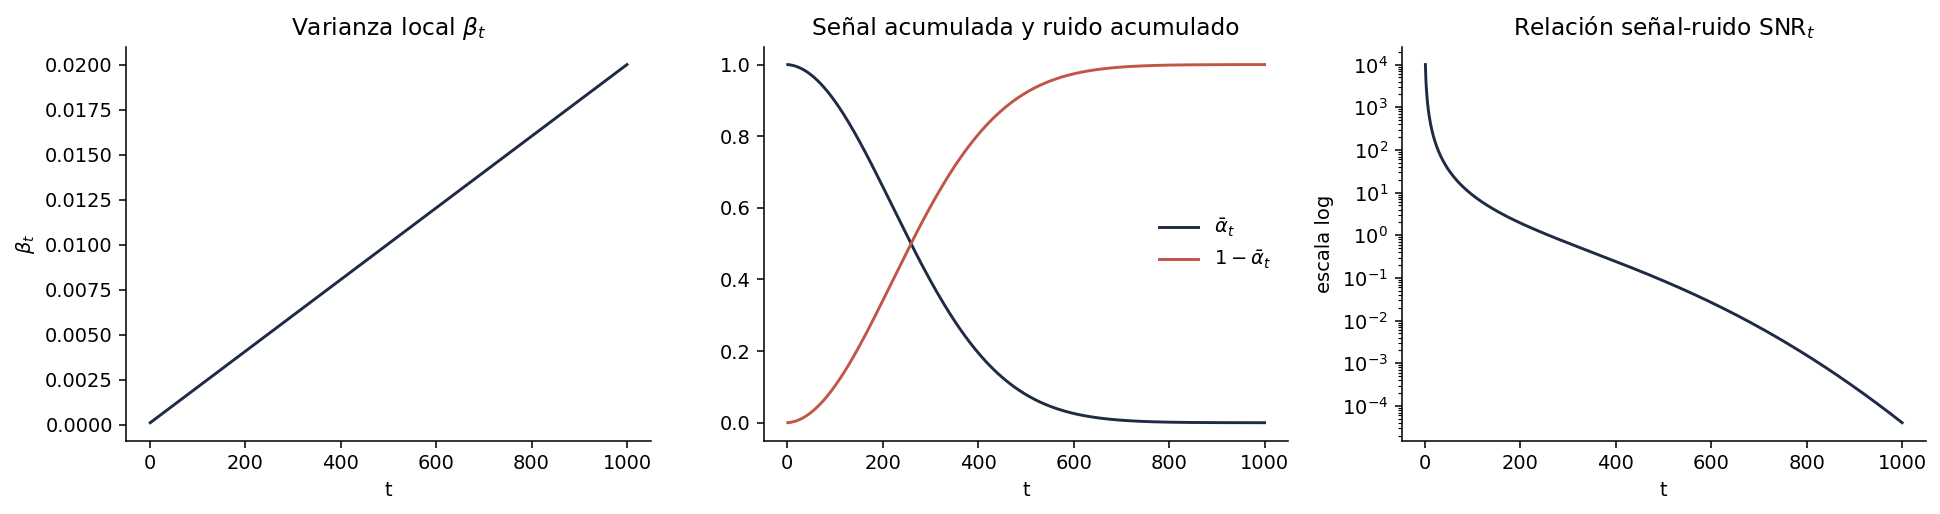

In [3]:
# Parámetros editables de la agenda de ruido.
T = 1000
beta_inicio = 1e-4
beta_fin = 2e-2

betas = np.linspace(beta_inicio, beta_fin, T, dtype=np.float64)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)
noise_fraction = 1.0 - alpha_bars
snr = alpha_bars / np.maximum(noise_fraction, 1e-12)

timesteps = np.arange(1, T + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(timesteps, betas, color="#1f2a44")
axes[0].set_title(r"Varianza local $\beta_t$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\beta_t$")

axes[1].plot(timesteps, alpha_bars, color="#1f2a44", label=r"$\bar{\alpha}_t$")
axes[1].plot(timesteps, noise_fraction, color="#c05746", label=r"$1-\bar{\alpha}_t$")
axes[1].set_title("Señal acumulada y ruido acumulado")
axes[1].set_xlabel("t")
axes[1].legend(frameon=False)

axes[2].plot(timesteps, snr, color="#1f2a44")
axes[2].set_yscale("log")
axes[2].set_title(r"Relación señal-ruido $\mathrm{SNR}_t$")
axes[2].set_xlabel("t")
axes[2].set_ylabel("escala log")

fig.tight_layout()

print(f"alpha_bar[1]    = {alpha_bars[0]:.6f}")
print(f"alpha_bar[T]    = {alpha_bars[-1]:.6f}")
print(f"SNR inicial     = {snr[0]:.2f}")
print(f"SNR final       = {snr[-1]:.6f}")


La agenda lineal hace que $\beta_t$ crezca lentamente. Aunque cada paso agrega poco ruido, el producto acumulado $\bar{\alpha}_t$ puede terminar cerca de cero después de muchos pasos. Esta acumulación es la razón por la cual el proceso directo puede convertir una imagen estructurada en una muestra visualmente parecida a ruido gaussiano.


## Muestreo directo de $x_t$

La forma cerrada permite tomar una imagen limpia $x_0$ y generar su versión ruidosa en cualquier tiempo sin simular los pasos anteriores:

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon.
$$

La función siguiente implementa exactamente esa ecuación. El índice `t_index` usa la convención de Python: `0` corresponde al primer paso y `T-1` al último.


In [4]:
def q_sample(x0, t_index, alpha_bars, rng):
    """Sample x_t from q(x_t | x_0) using the closed-form expression."""
    alpha_bar_t = alpha_bars[t_index]
    eps = rng.normal(size=x0.shape).astype(np.float32)
    xt = np.sqrt(alpha_bar_t) * x0 + np.sqrt(1.0 - alpha_bar_t) * eps
    return xt.astype(np.float32), eps


def to_image_range(x):
    """Map values from [-1, 1] approximately to [0, 1] for visualization."""
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def show_image(ax, image, title):
    ax.imshow(to_image_range(image), vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


## Trayectoria visual de una muestra

La siguiente visualización muestra una sola muestra $x_0$ a lo largo de diferentes tiempos. La imagen no desaparece de golpe. Primero se perturban los trazos, luego se pierde la estructura global y finalmente domina el ruido.


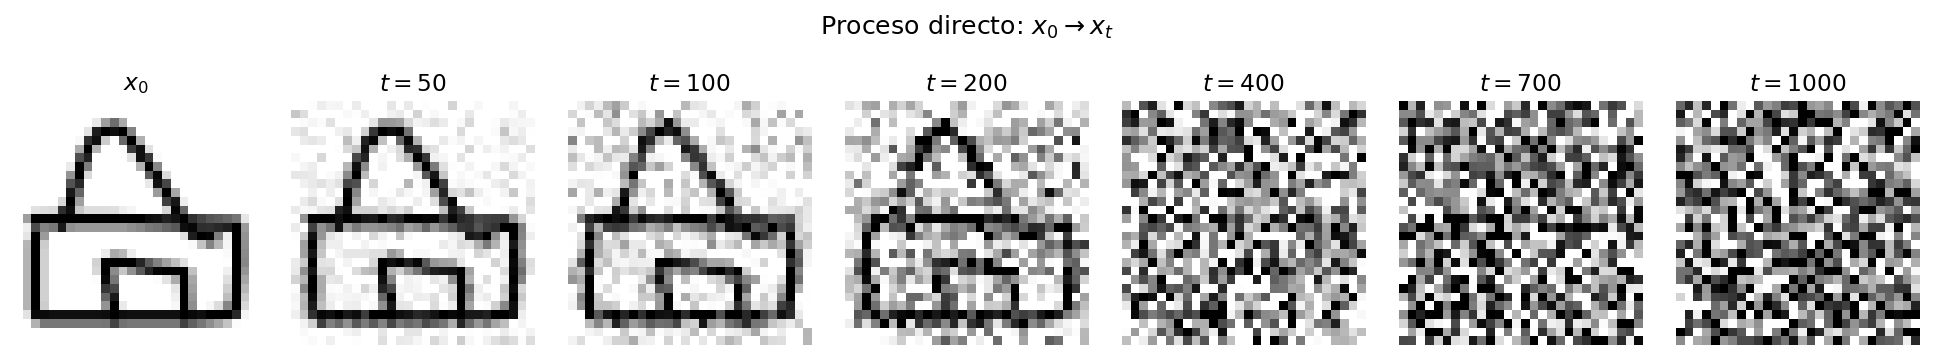

In [5]:
x0 = x_data[0]
selected_t = [0, 49, 99, 199, 399, 699, 999]

fig, axes = plt.subplots(1, len(selected_t), figsize=(14, 2.4))
for ax, t_index in zip(axes, selected_t):
    if t_index == 0:
        xt = x0
        title = r"$x_0$"
    else:
        xt, _ = q_sample(x0, t_index, alpha_bars, RNG)
        title = rf"$t={t_index + 1}$"
    show_image(ax, xt, title)

fig.suptitle(r"Proceso directo: $x_0 \rightarrow x_t$", y=1.05, fontsize=13)
fig.tight_layout()


La trayectoria visual corresponde a una familia de distribuciones condicionales $q(x_t \mid x_0)$. Para cada tiempo $t$, no hay una única imagen ruidosa posible: hay una distribución gaussiana centrada en $\sqrt{\bar{\alpha}_t}x_0$ con varianza $(1-\bar{\alpha}_t)I$.


## Variabilidad condicional

Para un mismo $x_0$ y un mismo tiempo $t$, diferentes valores de $\epsilon$ producen diferentes muestras de $x_t$. Esto es importante: el proceso directo es estocástico. La imagen limpia fija el centro de la distribución, pero el ruido determina la realización específica.


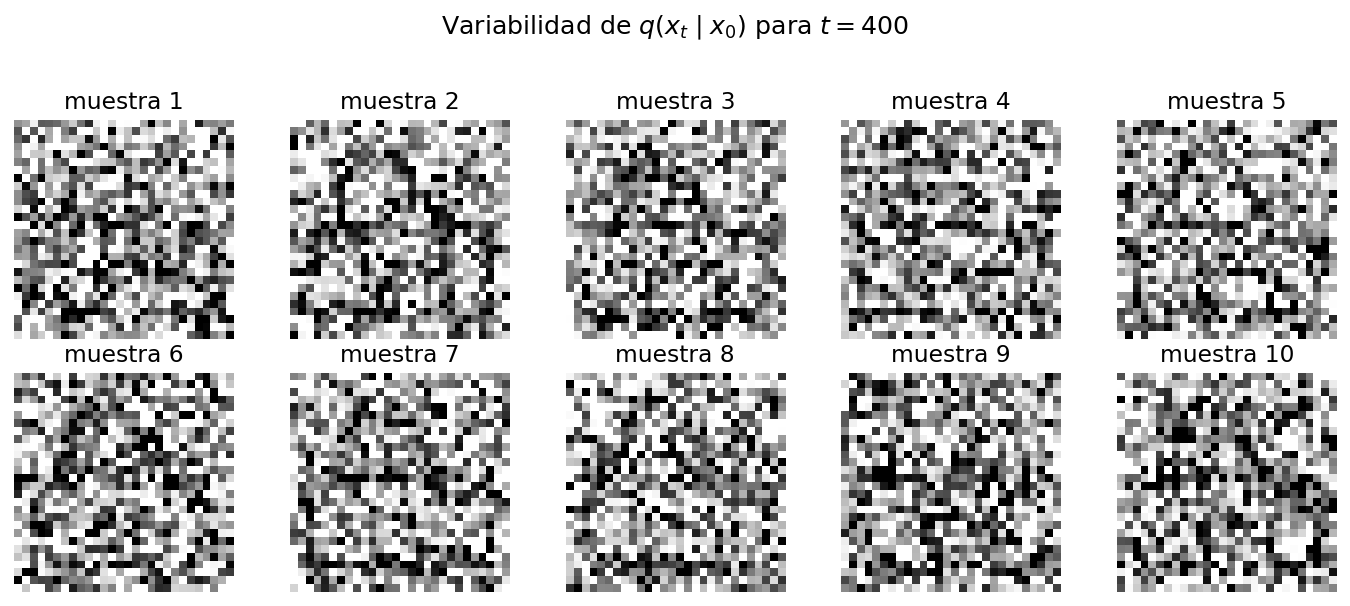

In [6]:
t_cond = 399
num_samples = 10
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
axes = axes.ravel()

for i, ax in enumerate(axes):
    xt, _ = q_sample(x0, t_cond, alpha_bars, RNG)
    show_image(ax, xt, rf"muestra {i + 1}")

fig.suptitle(rf"Variabilidad de $q(x_t \mid x_0)$ para $t={t_cond + 1}$", y=1.02, fontsize=13)
fig.tight_layout()


## Degradación de una muestra empírica

El proceso directo se aplica a cualquier muestra del dataset. La siguiente figura toma varias casas y muestra cómo cambian para los mismos tiempos. Esta visualización conecta la formulación con el dataset completo: no estamos diseñando ruido para una imagen particular, sino una transformación probabilística definida sobre el espacio de datos.


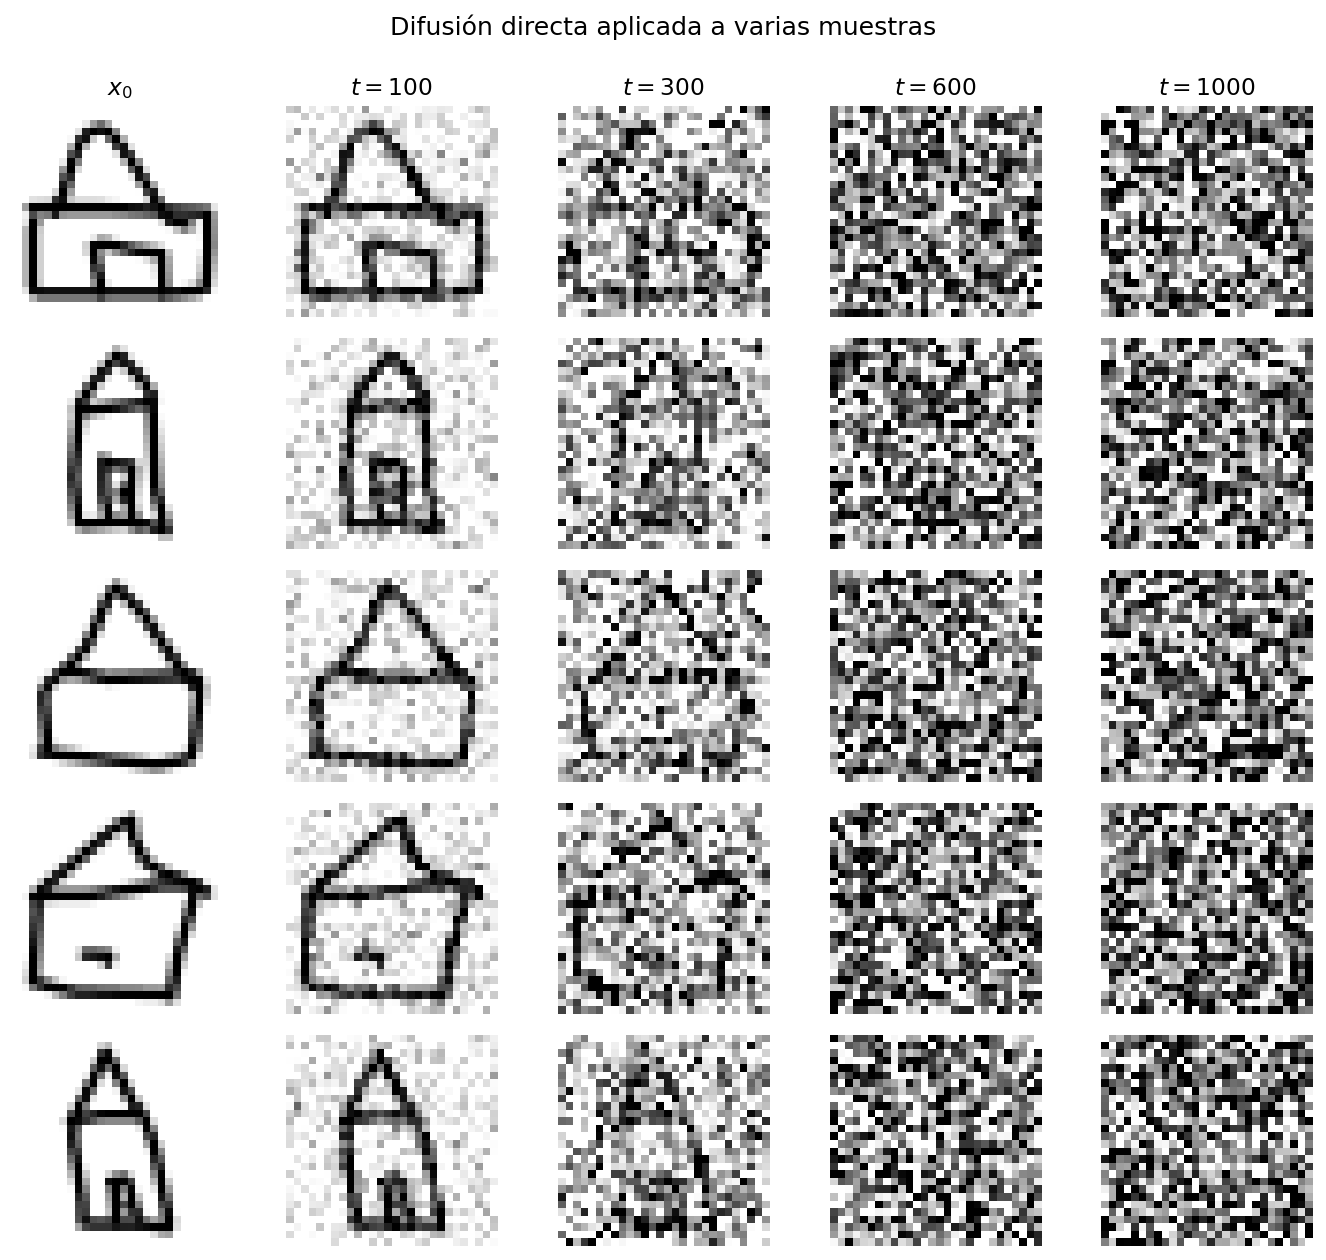

In [7]:
row_indices = [0, 7, 21, 42, 105]
row_times = [0, 99, 299, 599, 999]

fig, axes = plt.subplots(len(row_indices), len(row_times), figsize=(10, 9))
for row, img_idx in enumerate(row_indices):
    x0_row = x_data[img_idx]
    for col, t_index in enumerate(row_times):
        ax = axes[row, col]
        if t_index == 0:
            xt = x0_row
        else:
            xt, _ = q_sample(x0_row, t_index, alpha_bars, RNG)
        title = r"$x_0$" if t_index == 0 else rf"$t={t_index + 1}$"
        show_image(ax, xt, title if row == 0 else "")

fig.suptitle("Difusión directa aplicada a varias muestras", y=0.995, fontsize=13)
fig.tight_layout()


## Distribución de coordenadas

La forma cerrada también describe qué ocurre coordenada por coordenada. Para una coordenada fija $j$, si $x_{0,j}$ está dado, entonces

$$
x_{t,j}
\mid x_{0,j}
\sim
\mathcal{N}\left(
  \sqrt{\bar{\alpha}_t}\,x_{0,j},
  1-\bar{\alpha}_t
\right).
$$

La siguiente simulación verifica esta afirmación para una coordenada concreta. No es una demostración formal; es una comprobación computacional de que la ecuación que escribimos se traduce en una distribución observable.


pixel j = 370
x0_j = 1.000
media teórica = 0.442
media simulada = 0.446
varianza teórica = 0.805
varianza simulada = 0.814


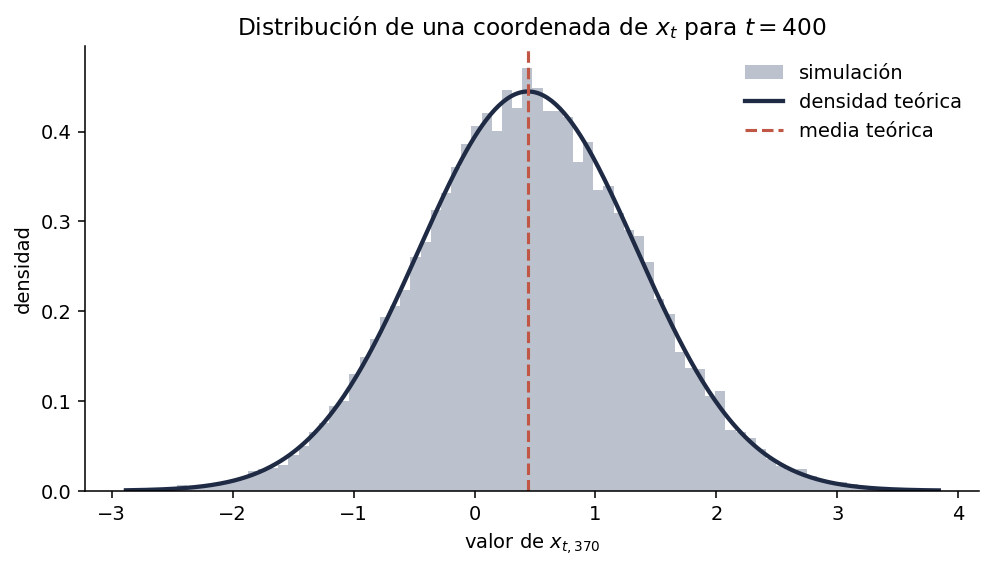

In [8]:
t_check = 399
pixel_index = 370
num_repetitions = 20_000

x0_vector = x0.reshape(-1)
x0_j = x0_vector[pixel_index]
alpha_bar_t = alpha_bars[t_check]
mean_theoretical = np.sqrt(alpha_bar_t) * x0_j
std_theoretical = np.sqrt(1.0 - alpha_bar_t)

noise = RNG.normal(size=num_repetitions)
xt_j = mean_theoretical + std_theoretical * noise

grid = np.linspace(xt_j.min(), xt_j.max(), 400)
density = (1 / (std_theoretical * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((grid - mean_theoretical) / std_theoretical) ** 2
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(xt_j, bins=80, density=True, alpha=0.65, color="#98a2b3", label="simulación")
ax.plot(grid, density, color="#1f2a44", linewidth=2.2, label="densidad teórica")
ax.axvline(mean_theoretical, color="#c05746", linestyle="--", linewidth=1.6, label="media teórica")
ax.set_title(rf"Distribución de una coordenada de $x_t$ para $t={t_check + 1}$")
ax.set_xlabel(rf"valor de $x_{{t,{pixel_index}}}$")
ax.set_ylabel("densidad")
ax.legend(frameon=False)
fig.tight_layout()

print(f"pixel j = {pixel_index}")
print(f"x0_j = {x0_j:.3f}")
print(f"media teórica = {mean_theoretical:.3f}")
print(f"media simulada = {xt_j.mean():.3f}")
print(f"varianza teórica = {1.0 - alpha_bar_t:.3f}")
print(f"varianza simulada = {xt_j.var():.3f}")


## Señal, ruido y pérdida de información

La ecuación de muestreo directo puede leerse como una mezcla controlada:

$$
x_t
=
\underbrace{\sqrt{\bar{\alpha}_t}\,x_0}_{\text{señal conservada}}
+
\underbrace{\sqrt{1-\bar{\alpha}_t}\,\epsilon}_{\text{ruido agregado}}.
$$

A medida que $t$ crece, el peso de la señal disminuye y el peso del ruido aumenta. La siguiente visualización muestra estos pesos junto con la relación señal-ruido.


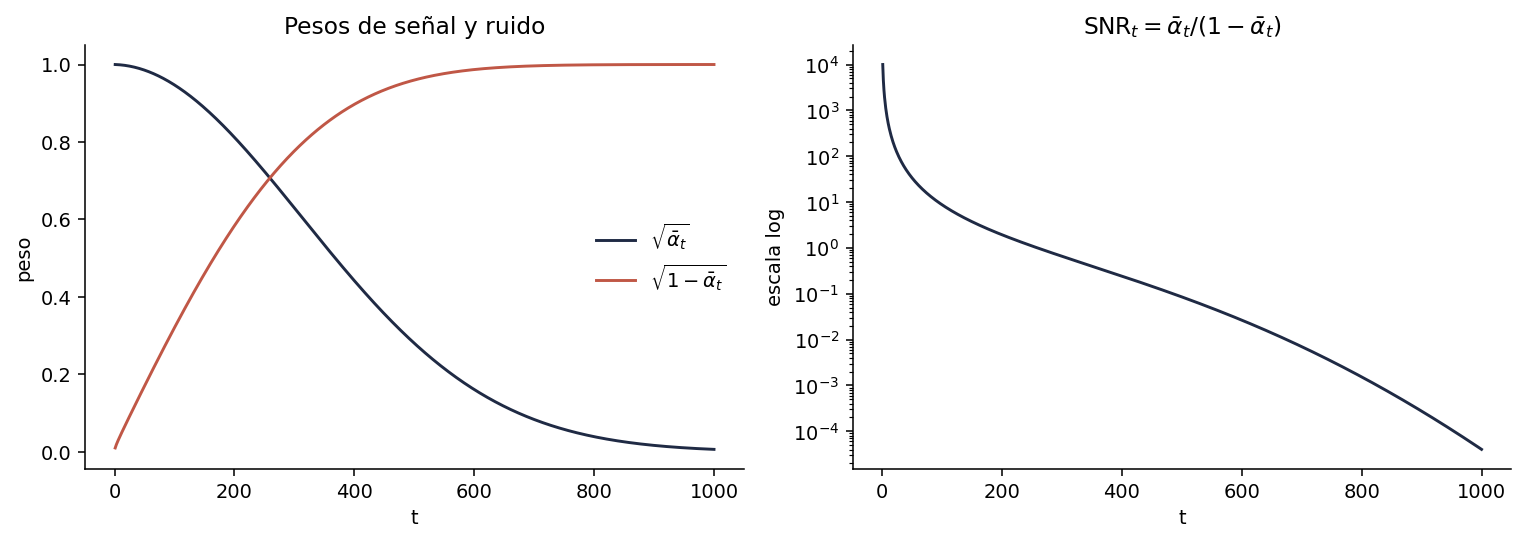

In [9]:
signal_weight = np.sqrt(alpha_bars)
noise_weight = np.sqrt(1.0 - alpha_bars)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(timesteps, signal_weight, label=r"$\sqrt{\bar{\alpha}_t}$", color="#1f2a44")
axes[0].plot(timesteps, noise_weight, label=r"$\sqrt{1-\bar{\alpha}_t}$", color="#c05746")
axes[0].set_title("Pesos de señal y ruido")
axes[0].set_xlabel("t")
axes[0].set_ylabel("peso")
axes[0].legend(frameon=False)

axes[1].plot(timesteps, snr, color="#1f2a44")
axes[1].set_yscale("log")
axes[1].set_title(r"$\mathrm{SNR}_t = \bar{\alpha}_t/(1-\bar{\alpha}_t)$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("escala log")

fig.tight_layout()


Esta figura resume el punto central del proceso directo: no se agrega ruido de forma arbitraria. La agenda controla una transición gradual desde una muestra estructurada hacia una distribución simple. Esa transición será invertida, de forma aproximada, por el modelo que entrenaremos más adelante.


## Lo que se aprende y lo que no se aprende

El proceso directo $q(x_t \mid x_{t-1})$ no contiene parámetros entrenables. La agenda $\beta_t$ se fija antes del entrenamiento y define cómo se corrompen los datos. Por eso, el proceso directo no es todavía un modelo generativo completo.

El aprendizaje aparecerá en el proceso inverso. Si el forward process transforma datos en ruido,

$$
q(x_t \mid x_{t-1})
\quad
\text{degrada información},
$$

entonces el modelo generativo buscará aproximar transiciones inversas,

$$
p_\theta(x_{t-1} \mid x_t),
$$

capaces de recuperar estructura paso a paso. Esta separación entre proceso directo fijo y proceso inverso aprendido es una de las ideas centrales de los modelos de difusión.


## Síntesis

**Resultado conceptual.** El proceso directo de difusión define una cadena gaussiana que transforma una muestra de datos $x_0$ en variables ruidosas $x_t$. La forma cerrada

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon
$$

permite simular cualquier tiempo directamente y muestra cómo se intercambian señal y ruido. Este proceso no se aprende; prepara el problema inverso que sí será aprendido por un modelo parametrizado.


## Preguntas de discusión

1. ¿Por qué el proceso directo se define como una cadena de Markov?
2. ¿Qué papel cumple $\beta_t$ en la transición $q(x_t \mid x_{t-1})$?
3. ¿Por qué $\bar{\alpha}_t$ resume el efecto acumulado de todos los pasos anteriores?
4. ¿Qué ventaja computacional tiene la forma cerrada $q(x_t \mid x_0)$?
5. ¿Por qué el proceso directo no es todavía un modelo generativo completo?
6. ¿Qué información visual se pierde primero cuando aumenta $t$ en imágenes de QuickDraw?
7. ¿Cómo se relaciona la SNR con la dificultad del problema inverso?


## Continuidad

El siguiente notebook formulará el problema de denoising inducido por este proceso directo. Allí usaremos pares sintéticos $(x_t,t)$ generados por la ecuación cerrada y estudiaremos qué cantidad debe aprender a predecir un modelo: la imagen limpia, el ruido agregado o una variable relacionada.
